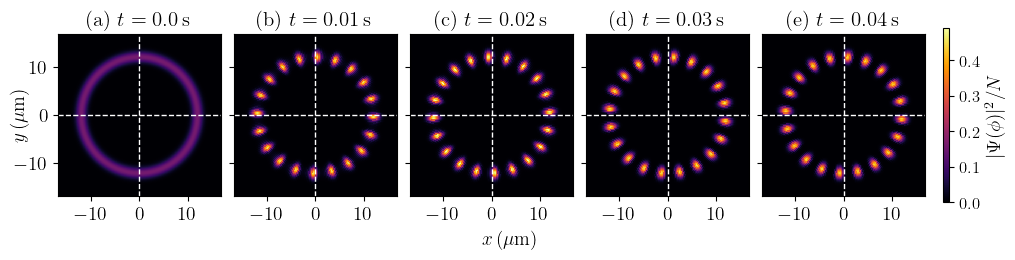

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD SAVED DATA
# ============================================================
save_file = r"Figure_4_data.npz"
data = np.load(save_file)

X = data["X"]
Y = data["Y"]
times_plot = data["times_plot"]
snapshots = data["snapshots"]
vmin = data["vmin"]
vmax = data["vmax"]

# ============================================================
# APS / LaTeX STYLE (same as before)
# ============================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "figure.facecolor": "white"
})


# ============================================================
# FIGURE SETUP
# ============================================================
fig, axes = plt.subplots(1, len(times_plot), figsize=(10, 3), constrained_layout=True)

letters = ['a', 'b', 'c', 'd', 'e']

# ============================================================
# PLOTTING LOOP
# ============================================================
for i, ax in enumerate(axes):

    im = ax.pcolormesh(
        X * 1e6,
        Y * 1e6,
        snapshots[i],
        shading="auto",
        cmap="inferno",
        vmin=vmin,
        vmax=vmax
    )

    # guide lines
    ax.axhline(y=0, color='white', linestyle='--', linewidth=1)
    ax.axvline(x=0, color='white', linestyle='--', linewidth=1)

    ax.set_aspect("equal")
    ax.set_xticks([-10, 0, 10])
    ax.set_yticks([-10, 0, 10])

    if i != 0:
        ax.set_yticklabels([])

    ax.set_title(rf"({letters[i]}) $t={times_plot[i]}\,\mathrm{{s}}$", fontsize=15)

# ============================================================
# COMMON LABELS
# ============================================================
fig.supxlabel(r"$x\,(\mu\mathrm{m})$", fontsize=14, y=0.05)
fig.supylabel(r"$y\,(\mu\mathrm{m})$", fontsize=14, x=0.0)

# ============================================================
# COLORBAR
# ============================================================
cbar = fig.colorbar(
    im,
    ax=axes,
    fraction=0.065,
    pad=0.02,
    shrink=0.6,
    aspect=28
)

cbar.set_label(r"$|\Psi(\phi)|^2/N$", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.show()